# LOSO CV: Daily Batch SGD — MT, ID, ND, SD, WY

Multi-state batchwise LOSO with daily batching (1 complete day per epoch).
After training each fold, sweeps inference conditioning sizes to show how
test loss varies with the number of conditioning days.

**Kernel:** `Base_RBF_ARD + AOT×Season + SmogI/P×Season + Residual_Season`

In [1]:
# Training already completed — results loaded from saved files
# To re-run: python loso_cv_daily_parallel.py --n_days 1 --n_epochs 1000 --patience 30 \
#   --inference_days '25,50,100,150,200,250,300,350,400' --n_gpus 4
print("Loading pre-computed results...")

Loading pre-computed results...


## Results

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open('daily_parallel_results.json') as f:
    results = json.load(f)

metrics_df = pd.read_csv('daily_parallel_site_metrics.csv')
params_df = pd.read_csv('daily_parallel_kernel_params.csv')
timing_df = pd.read_csv('daily_parallel_fold_timings.csv')
sweep_df = pd.read_csv('daily_parallel_inference_sweep.csv')
data = np.load('daily_parallel_predictions.npz')

print('=' * 60)
print('LOSO CV Results (Daily Batch SGD, MT/ID/ND/SD/WY)')
print('=' * 60)
o = results['overall']
c = results['config']
print(f"Training: {c['training']}, n_days={c['n_days']}, patience={c['patience']}")
print(f"States: {c['states']}")
print(f"Log scale:  RMSE={o['rmse_log']:.4f}, MAE={o['mae_log']:.4f}, R²={o['r2_log']:.4f}")
print(f"Orig scale: RMSE={o['rmse_orig']:.2f}, MAE={o['mae_orig']:.2f}, R²={o['r2_orig']:.4f}")
print(f"Total time: {o['total_time']:.1f}s")
print(f"Sites: {len(metrics_df)}, Predictions: {o['n_predictions']}")
print()
print("Batch structure:")
print(f"  Avg batch size: {timing_df['avg_batch_size'].mean():.0f} obs/epoch")
print(f"  Stopped epochs: mean={timing_df['stopped_epoch'].mean():.0f}, "
      f"min={timing_df['stopped_epoch'].min()}, max={timing_df['stopped_epoch'].max()}")
print()
print("Per-state site counts and R²:")
for st in c['states']:
    st_metrics = metrics_df[metrics_df['state'] == st]
    if len(st_metrics) > 0:
        print(f"  {st}: {len(st_metrics)} sites, median R²={st_metrics['r2_log'].median():.3f}")
print()
print("Overall site-level R² summary:")
print(metrics_df['r2_log'].describe())

LOSO CV Results (Daily Batch SGD, MT/ID/ND/SD/WY)
Training: daily_batch_sgd, n_days=1, patience=30
States: ['MT', 'ID', 'ND', 'SD', 'WY']
Log scale:  RMSE=0.5471, MAE=0.4220, R²=0.3979
Orig scale: RMSE=4.54, MAE=2.68, R²=0.4497
Total time: 607.5s
Sites: 112, Predictions: 48852

Batch structure:
  Avg batch size: 66 obs/epoch
  Stopped epochs: mean=94, min=58, max=203

Per-state site counts and R²:
  MT: 32 sites, median R²=0.294
  ID: 38 sites, median R²=0.099
  ND: 6 sites, median R²=-0.038
  SD: 2 sites, median R²=0.379
  WY: 34 sites, median R²=0.309

Overall site-level R² summary:
count    112.000000
mean      -0.730977
std        5.082040
min      -48.841323
25%       -0.118693
50%        0.219577
75%        0.409551
max        0.755421
Name: r2_log, dtype: float64


## Inference Size Sweep

How does test loss change as we condition on more training days at inference time?

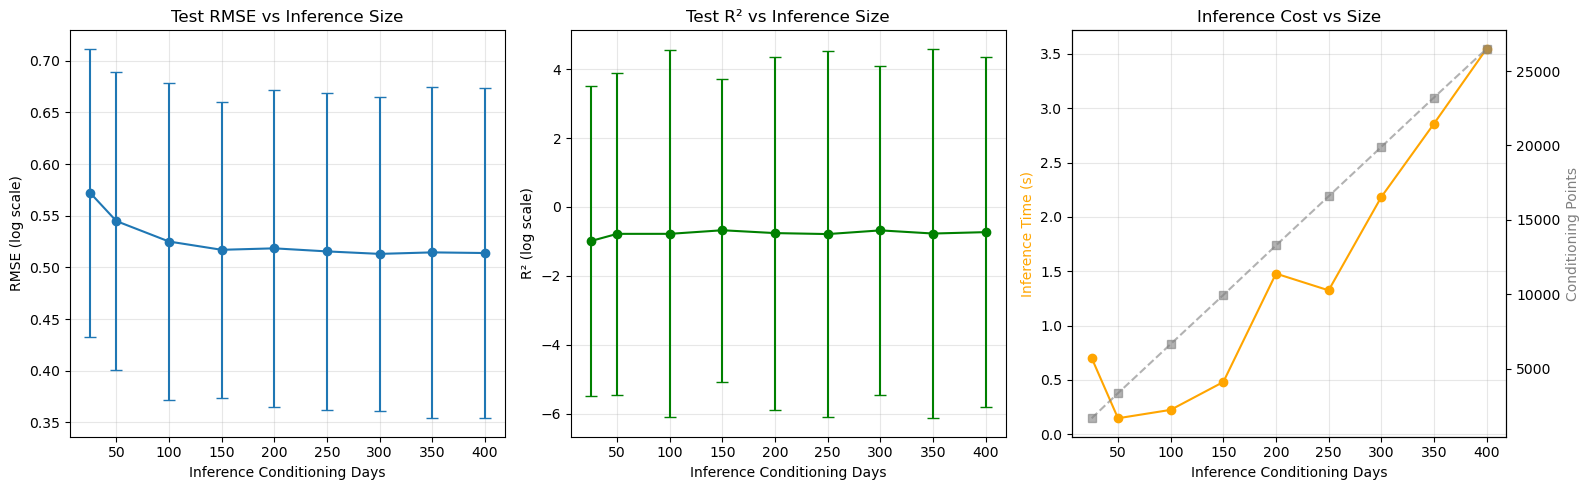

 inference_days  mean_n_points  mean_rmse  mean_mae   mean_r2  mean_infer_time
             25    1659.187500   0.572297  0.457278 -0.989833         0.702184
             50    3343.937500   0.544847  0.436931 -0.780724         0.147796
            100    6644.750000   0.525062  0.420714 -0.780426         0.225002
            150    9943.910714   0.517056  0.414466 -0.676304         0.481355
            200   13277.214286   0.518469  0.416983 -0.758904         1.478445
            250   16583.116071   0.515510  0.414231 -0.787001         1.324514
            300   19899.142857   0.513105  0.412143 -0.680067         2.182947
            350   23221.267857   0.514558  0.414827 -0.771397         2.857114
            400   26498.517857   0.513939  0.413288 -0.730977         3.546278


In [3]:
# Aggregate sweep: overall mean across all folds
sweep_overall = sweep_df.groupby('inference_days').agg(
    mean_rmse=('rmse_log', 'mean'),
    std_rmse=('rmse_log', 'std'),
    mean_mae=('mae_log', 'mean'),
    std_mae=('mae_log', 'std'),
    mean_r2=('r2_log', 'mean'),
    std_r2=('r2_log', 'std'),
    mean_infer_time=('infer_time', 'mean'),
    mean_n_points=('n_infer_points', 'mean'),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# RMSE vs inference days
axes[0].errorbar(sweep_overall['inference_days'], sweep_overall['mean_rmse'],
                 yerr=sweep_overall['std_rmse'], marker='o', capsize=4)
axes[0].set_xlabel('Inference Conditioning Days')
axes[0].set_ylabel('RMSE (log scale)')
axes[0].set_title('Test RMSE vs Inference Size')
axes[0].grid(True, alpha=0.3)

# R² vs inference days
axes[1].errorbar(sweep_overall['inference_days'], sweep_overall['mean_r2'],
                 yerr=sweep_overall['std_r2'], marker='o', capsize=4, color='green')
axes[1].set_xlabel('Inference Conditioning Days')
axes[1].set_ylabel('R² (log scale)')
axes[1].set_title('Test R² vs Inference Size')
axes[1].grid(True, alpha=0.3)

# Inference time vs inference days
axes[2].plot(sweep_overall['inference_days'], sweep_overall['mean_infer_time'],
             marker='o', color='orange')
ax2 = axes[2].twinx()
ax2.plot(sweep_overall['inference_days'], sweep_overall['mean_n_points'],
         marker='s', color='gray', linestyle='--', alpha=0.6)
ax2.set_ylabel('Conditioning Points', color='gray')
axes[2].set_xlabel('Inference Conditioning Days')
axes[2].set_ylabel('Inference Time (s)', color='orange')
axes[2].set_title('Inference Cost vs Size')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(sweep_overall[['inference_days', 'mean_n_points', 'mean_rmse', 'mean_mae',
                      'mean_r2', 'mean_infer_time']].to_string(index=False))

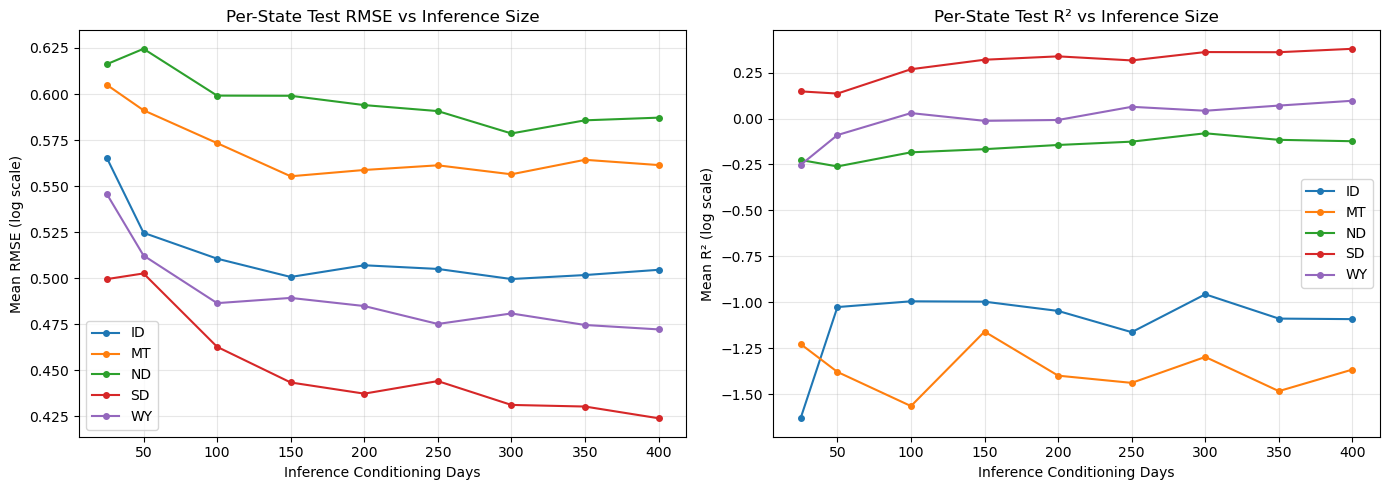

In [4]:
# Per-state inference sweep
states = sorted(sweep_df['state'].unique())
n_states = len(states)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for st in states:
    st_sweep = sweep_df[sweep_df['state'] == st].groupby('inference_days').agg(
        mean_rmse=('rmse_log', 'mean'),
        mean_r2=('r2_log', 'mean'),
    ).reset_index()
    axes[0].plot(st_sweep['inference_days'], st_sweep['mean_rmse'], marker='o', label=st, markersize=4)
    axes[1].plot(st_sweep['inference_days'], st_sweep['mean_r2'], marker='o', label=st, markersize=4)

axes[0].set_xlabel('Inference Conditioning Days')
axes[0].set_ylabel('Mean RMSE (log scale)')
axes[0].set_title('Per-State Test RMSE vs Inference Size')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Inference Conditioning Days')
axes[1].set_ylabel('Mean R² (log scale)')
axes[1].set_title('Per-State Test R² vs Inference Size')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Training Loss

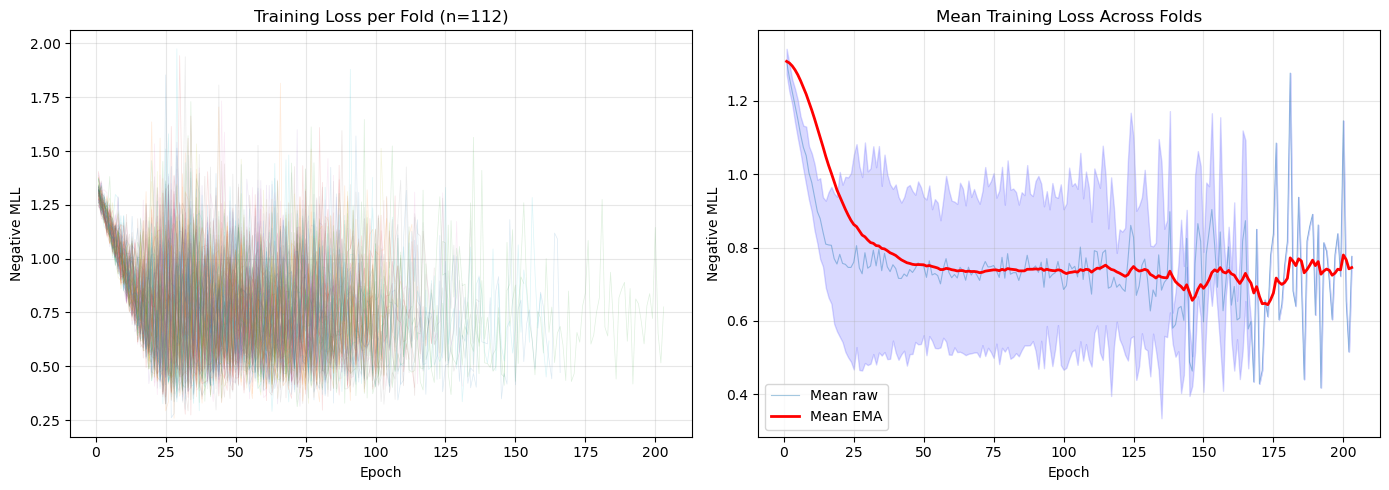

Min mean raw loss at epoch 192: 0.4175
Final EMA: 0.7454


In [5]:
fold_losses = results['fold_losses']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for site, losses in fold_losses.items():
    axes[0].plot(range(1, len(losses)+1), losses, alpha=0.15, linewidth=0.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Negative MLL')
axes[0].set_title(f'Training Loss per Fold (n={len(fold_losses)})')
axes[0].grid(True, alpha=0.3)

max_len = max(len(v) for v in fold_losses.values())
loss_matrix = np.full((len(fold_losses), max_len), np.nan)
for i, losses in enumerate(fold_losses.values()):
    loss_matrix[i, :len(losses)] = losses
mean_loss = np.nanmean(loss_matrix, axis=0)
std_loss = np.nanstd(loss_matrix, axis=0)
epochs = np.arange(1, len(mean_loss)+1)

ema = [mean_loss[0]]
for l in mean_loss[1:]:
    ema.append(0.9 * ema[-1] + 0.1 * (l if not np.isnan(l) else ema[-1]))

axes[1].plot(epochs, mean_loss, alpha=0.4, linewidth=0.8, label='Mean raw')
axes[1].plot(epochs[:len(ema)], ema, 'r-', linewidth=2, label='Mean EMA')
axes[1].fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss,
                     alpha=0.15, color='blue')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Negative MLL')
axes[1].set_title('Mean Training Loss Across Folds')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

min_epoch = np.nanargmin(mean_loss) + 1
print(f'Min mean raw loss at epoch {min_epoch}: {np.nanmin(mean_loss):.4f}')
print(f'Final EMA: {ema[-1]:.4f}')

## Predictions (largest inference size)

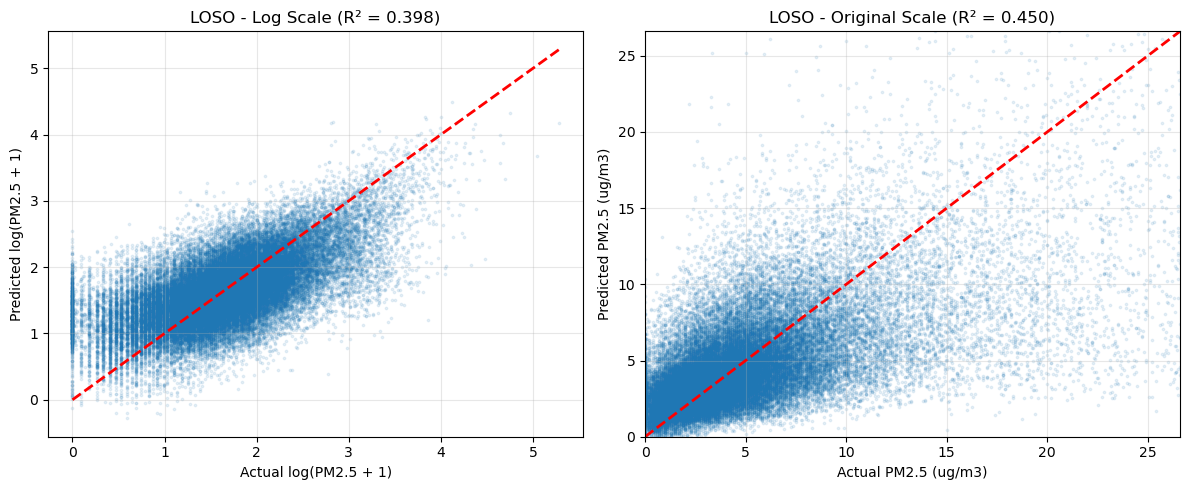

In [6]:
all_pred = data['predictions']
all_actual = data['actuals']
pred_pm25 = data['pred_pm25']
actual_pm25 = data['actual_pm25']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(all_actual, all_pred, alpha=0.1, s=3)
axes[0].plot([all_actual.min(), all_actual.max()],
             [all_actual.min(), all_actual.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual log(PM2.5 + 1)')
axes[0].set_ylabel('Predicted log(PM2.5 + 1)')
axes[0].set_title(f'LOSO - Log Scale (R² = {o["r2_log"]:.3f})')
axes[0].grid(True, alpha=0.3)

max_val = np.percentile(np.concatenate([actual_pm25, pred_pm25]), 99)
axes[1].scatter(actual_pm25, pred_pm25, alpha=0.1, s=3)
axes[1].plot([0, max_val], [0, max_val], 'r--', lw=2)
axes[1].set_xlabel('Actual PM2.5 (ug/m3)')
axes[1].set_ylabel('Predicted PM2.5 (ug/m3)')
axes[1].set_title(f'LOSO - Original Scale (R² = {o["r2_orig"]:.3f})')
axes[1].set_xlim(0, max_val)
axes[1].set_ylim(0, max_val)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Site-Level Analysis

/tmp/ipykernel_1906713/2143983083.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[2].boxplot(state_r2_data, labels=states, patch_artist=True)


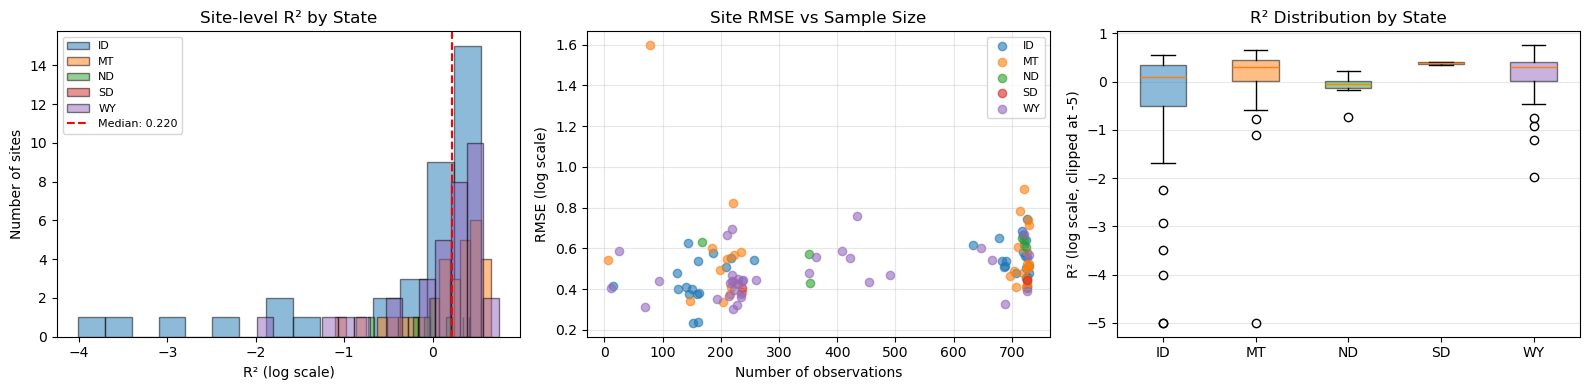

Top 5 best sites:
        site state  n_obs  rmse_log   r2_log
110401_44565    WY    221  0.303779 0.755421
111712_46826    MT    147  0.340998 0.662792
115672_47955    MT    218  0.411919 0.628708
114001_45860    MT    236  0.385471 0.624132
105290_44652    WY    228  0.322105 0.609714

Top 5 worst sites:
        site state  n_obs  rmse_log     r2_log
115195_48971    MT     78  1.596723 -48.841323
113787_42608    ID    161  0.536507 -19.420548
116979_44262    ID    141  0.408546  -9.627581
116359_48998    ID    126  0.399623  -4.011569
116359_48894    ID    124  0.478133  -3.497557


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# R² distribution by state
states = sorted(metrics_df['state'].unique())
colors = plt.cm.tab10(range(len(states)))
for i, st in enumerate(states):
    st_r2 = metrics_df[metrics_df['state'] == st]['r2_log'].dropna()
    st_r2_clipped = st_r2[st_r2 > -5]
    axes[0].hist(st_r2_clipped, bins=15, alpha=0.5, label=st, color=colors[i], edgecolor='black')
axes[0].axvline(x=metrics_df['r2_log'].median(), color='r', linestyle='--',
                label=f'Median: {metrics_df["r2_log"].median():.3f}')
axes[0].set_xlabel('R² (log scale)')
axes[0].set_ylabel('Number of sites')
axes[0].set_title('Site-level R² by State')
axes[0].legend(fontsize=8)

# RMSE vs sample size, colored by state
for i, st in enumerate(states):
    mask = metrics_df['state'] == st
    axes[1].scatter(metrics_df.loc[mask, 'n_obs'], metrics_df.loc[mask, 'rmse_log'],
                    alpha=0.6, label=st, color=colors[i])
axes[1].set_xlabel('Number of observations')
axes[1].set_ylabel('RMSE (log scale)')
axes[1].set_title('Site RMSE vs Sample Size')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Box plot of R² by state
state_r2_data = [metrics_df[metrics_df['state'] == st]['r2_log'].clip(lower=-5).values
                 for st in states]
bp = axes[2].boxplot(state_r2_data, labels=states, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
axes[2].set_ylabel('R² (log scale, clipped at -5)')
axes[2].set_title('R² Distribution by State')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('Top 5 best sites:')
print(metrics_df.nlargest(5, 'r2_log')[['site', 'state', 'n_obs', 'rmse_log', 'r2_log']].to_string(index=False))
print()
print('Top 5 worst sites:')
print(metrics_df.nsmallest(5, 'r2_log')[['site', 'state', 'n_obs', 'rmse_log', 'r2_log']].to_string(index=False))

## Kernel Parameters

In [8]:
print('Learned kernel output scales:')
print(f"{'Component':<25} {'Mean':>8} {'Std':>8}")
print('-' * 45)
for col, label in [('base_scale', 'Base RBF_ARD'),
                    ('summer_scale', 'AOT x Season'),
                    ('winter_scale', 'SmogI/P x Season'),
                    ('seasonal_scale', 'Residual Seasonal')]:
    print(f'{label:<25} {params_df[col].mean():>8.4f} {params_df[col].std():>8.4f}')

print()
print('Learned periods (days):')
for col, label in [('aot_period_days', 'AOT periodic'),
                    ('smog_period_days', 'Smog periodic'),
                    ('residual_period_days', 'Residual periodic')]:
    print(f'{label:<25} {params_df[col].mean():>8.1f} {params_df[col].std():>8.1f}')

print()
print(f'Noise: mean={params_df["noise"].mean():.4f}, std={params_df["noise"].std():.4f}')

Learned kernel output scales:
Component                     Mean      Std
---------------------------------------------
Base RBF_ARD                0.0980   0.0116
AOT x Season                0.0480   0.0180
SmogI/P x Season            0.2810   0.0581
Residual Seasonal           0.1109   0.1193

Learned periods (days):
AOT periodic                 365.3      0.0
Smog periodic                365.3      0.0
Residual periodic            365.3      0.0

Noise: mean=0.1320, std=0.0190


## Convergence Analysis

/tmp/ipykernel_1906713/3986774851.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(epoch_data, labels=states, patch_artist=True)


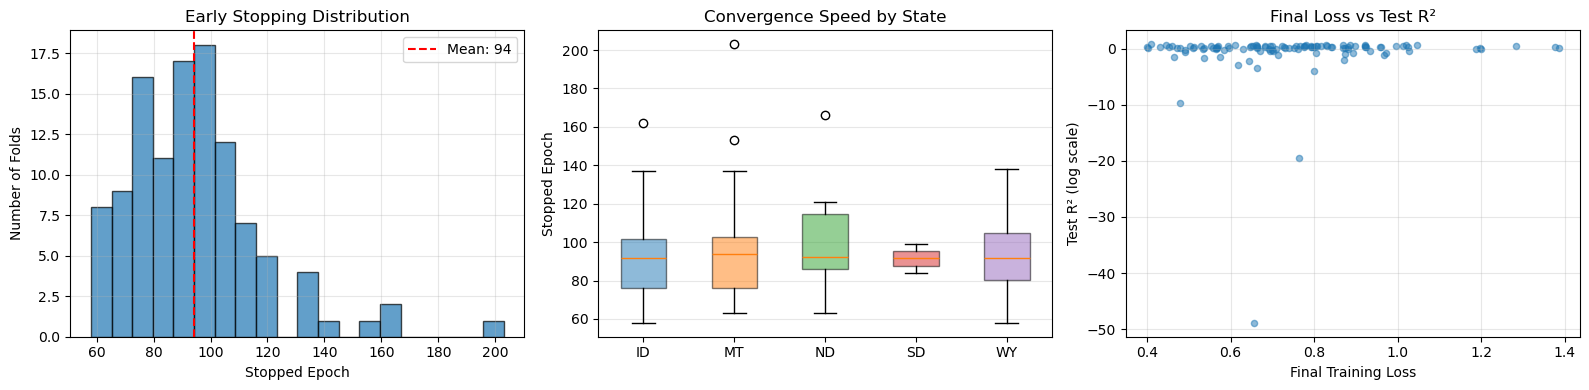

Convergence summary:
  Mean stopped epoch: 94
  Median stopped epoch: 92
  Folds reaching max epochs: 0


In [9]:
# Convergence: stopped epoch distribution and per-state breakdown
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Overall stopped epoch histogram
axes[0].hist(timing_df['stopped_epoch'], bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(timing_df['stopped_epoch'].mean(), color='r', linestyle='--',
                label=f'Mean: {timing_df["stopped_epoch"].mean():.0f}')
axes[0].set_xlabel('Stopped Epoch')
axes[0].set_ylabel('Number of Folds')
axes[0].set_title('Early Stopping Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Per-state stopped epoch box plot
states = sorted(timing_df['state'].unique())
colors = plt.cm.tab10(range(len(states)))
epoch_data = [timing_df[timing_df['state'] == st]['stopped_epoch'].values for st in states]
bp = axes[1].boxplot(epoch_data, labels=states, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
axes[1].set_ylabel('Stopped Epoch')
axes[1].set_title('Convergence Speed by State')
axes[1].grid(True, alpha=0.3, axis='y')

# Loss at convergence vs R²
final_losses = []
for site, losses in fold_losses.items():
    final_losses.append(losses[-1])
site_order = list(fold_losses.keys())
r2_vals = []
for s in site_order:
    r2_row = metrics_df[metrics_df['site'] == s]
    r2_vals.append(r2_row['r2_log'].values[0] if len(r2_row) > 0 else np.nan)

axes[2].scatter(final_losses, r2_vals, alpha=0.5, s=20)
axes[2].set_xlabel('Final Training Loss')
axes[2].set_ylabel('Test R² (log scale)')
axes[2].set_title('Final Loss vs Test R²')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Convergence summary:")
print(f"  Mean stopped epoch: {timing_df['stopped_epoch'].mean():.0f}")
print(f"  Median stopped epoch: {timing_df['stopped_epoch'].median():.0f}")
print(f"  Folds reaching max epochs: {(timing_df['stopped_epoch'] == c['n_epochs']).sum()}")

## Timings

/tmp/ipykernel_1906713/1168617507.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[2].boxplot(fold_time_data, labels=states, patch_artist=True)


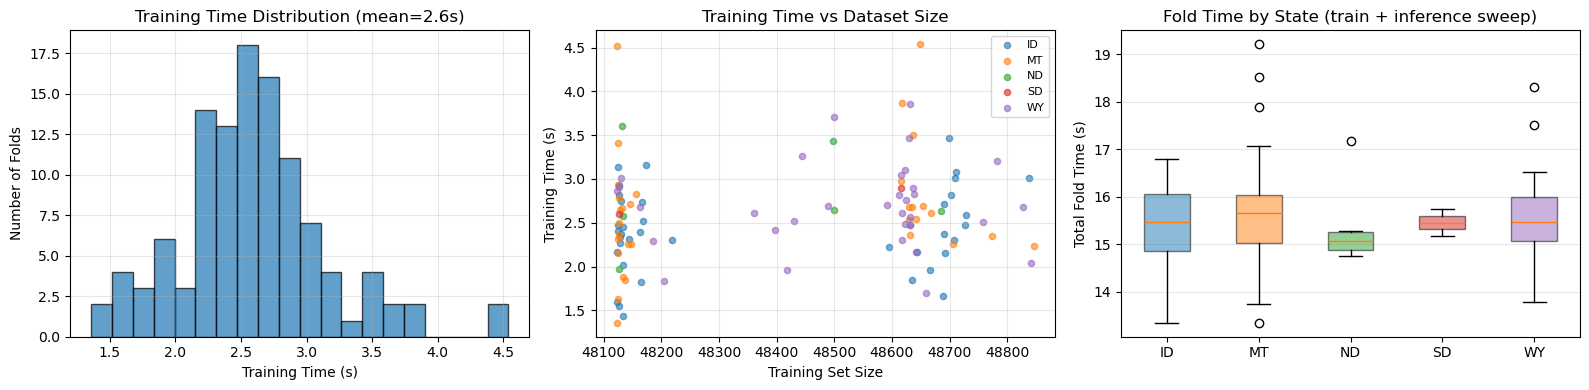

Timing summary:
  Total wall time: 607.5s (10.1 min)
  Mean training time per fold: 2.6s
  Mean total fold time: 15.5s
  Avg batch size: 66 obs/epoch

Per-state timing:
  ID: 38 folds, mean train=2.4s, mean fold=15.4s
  MT: 32 folds, mean train=2.7s, mean fold=15.7s
  ND: 6 folds, mean train=2.8s, mean fold=15.4s
  SD: 2 folds, mean train=2.8s, mean fold=15.5s
  WY: 34 folds, mean train=2.7s, mean fold=15.6s


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Training time distribution
axes[0].hist(timing_df['train_time'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Training Time (s)')
axes[0].set_ylabel('Number of Folds')
axes[0].set_title(f'Training Time Distribution (mean={timing_df["train_time"].mean():.1f}s)')
axes[0].grid(True, alpha=0.3)

# Training time vs n_train
for i, st in enumerate(states):
    mask = timing_df['state'] == st
    axes[1].scatter(timing_df.loc[mask, 'n_train'], timing_df.loc[mask, 'train_time'],
                    alpha=0.6, label=st, color=colors[i], s=20)
axes[1].set_xlabel('Training Set Size')
axes[1].set_ylabel('Training Time (s)')
axes[1].set_title('Training Time vs Dataset Size')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Fold time by state
fold_time_data = [timing_df[timing_df['state'] == st]['fold_time'].values for st in states]
bp = axes[2].boxplot(fold_time_data, labels=states, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
axes[2].set_ylabel('Total Fold Time (s)')
axes[2].set_title('Fold Time by State (train + inference sweep)')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Timing summary:")
print(f"  Total wall time: {o['total_time']:.1f}s ({o['total_time']/60:.1f} min)")
print(f"  Mean training time per fold: {timing_df['train_time'].mean():.1f}s")
print(f"  Mean total fold time: {timing_df['fold_time'].mean():.1f}s")
print(f"  Avg batch size: {timing_df['avg_batch_size'].mean():.0f} obs/epoch")
print()
print("Per-state timing:")
for st in states:
    st_t = timing_df[timing_df['state'] == st]
    print(f"  {st}: {len(st_t)} folds, mean train={st_t['train_time'].mean():.1f}s, "
          f"mean fold={st_t['fold_time'].mean():.1f}s")